# Classification

**Regression**: Represent the distribution as line. (Continuos)

**Classification**: Separate the data into classes.

In [1]:
import warnings
warnings.simplefilter(action='ignore')

In [2]:
from sklearn import datasets

iris = datasets.load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [3]:
import pandas as pd
import numpy as np

df = pd.DataFrame(data=np.c_[iris['data'], iris['target']],
                 columns=iris['feature_names']+['target'])

df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [4]:
from sklearn.model_selection import train_test_split

x = iris.data
y = iris.target

xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size=0.25, random_state=42)

dfTest = pd.DataFrame(data=np.c_[xTest, yTest],
                 columns=iris['feature_names']+['target'])

dfTest

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,6.1,2.8,4.7,1.2,1.0
1,5.7,3.8,1.7,0.3,0.0
2,7.7,2.6,6.9,2.3,2.0
3,6.0,2.9,4.5,1.5,1.0
4,6.8,2.8,4.8,1.4,1.0
5,5.4,3.4,1.5,0.4,0.0
6,5.6,2.9,3.6,1.3,1.0
7,6.9,3.1,5.1,2.3,2.0
8,6.2,2.2,4.5,1.5,1.0
9,5.8,2.7,3.9,1.2,1.0


In [5]:
x = iris.data[:, 2:]

xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size=0.3, random_state=1)

dfTest = pd.DataFrame(data=np.c_[xTest, yTest],
                 columns=iris['feature_names'][2:]+['target'])

dfTest

,petal length (cm),petal width (cm),target
0,1.2,0.2,0.0
1,3.0,1.1,1.0
2,4.4,1.4,1.0
3,1.3,0.4,0.0
4,6.4,2.0,2.0
5,4.7,1.6,1.0
6,5.1,2.3,2.0
7,1.9,0.4,0.0
8,1.6,0.2,0.0
9,5.7,2.3,2.0


## First try

In [6]:
from sklearn.dummy import DummyClassifier

dum = DummyClassifier(strategy='stratified')
dum.fit(xTrain, yTrain)

from sklearn.metrics import classification_report

dumPred = dum.predict(xTest)

print(classification_report(yTest, dumPred))

              precision    recall  f1-score   support

           0       0.42      0.57      0.48        14
           1       0.42      0.28      0.33        18
           2       0.36      0.38      0.37        13

    accuracy                           0.40        45
   macro avg       0.40      0.41      0.40        45
weighted avg       0.40      0.40      0.39        45



In [7]:
print(dumPred)
print(yTest)

[0 2 2 1 2 0 1 2 1 1 0 0 0 2 0 0 1 1 0 0 1 2 0 1 2 2 0 0 0 2 1 0 2 0 1 0 0
 2 2 2 0 1 2 0 1]
[0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 1 0 2 1 0 0 1 2 1 2 1 2 2 0 1
 0 1 2 2 0 2 2 1]


In [8]:
dumProb = dum.predict_proba(xTest)

from sklearn.metrics import balanced_accuracy_score, f1_score, log_loss

print("Accuracy: ", balanced_accuracy_score(yTest, dumPred))
print("F1: ", f1_score(yTest, dumPred, average='weighted'))
print("Loss: ", log_loss(yTest, dumProb))

Accuracy:  0.4112739112739113
F1:  0.3911709689487468
Loss:  21.626192033470293


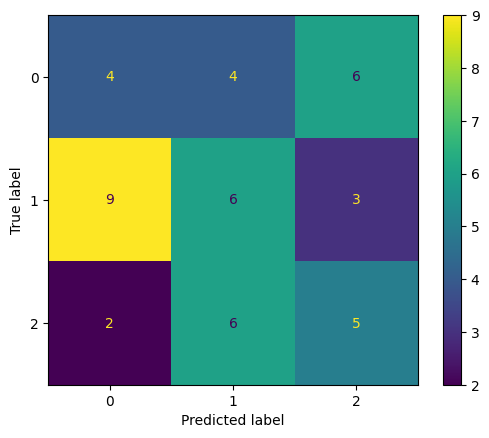

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt 
%matplotlib inline

ConfusionMatrixDisplay.from_estimator(dum, xTest, yTest)

In [17]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "mlxtend"])

0

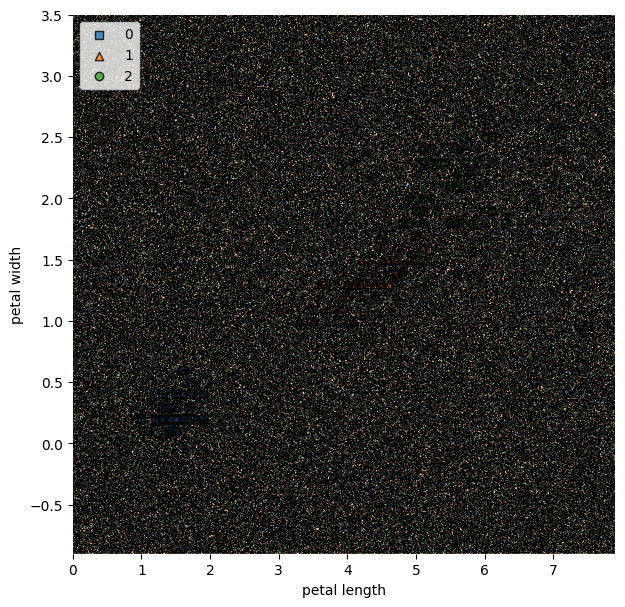

In [16]:
from mlxtend.plotting import plot_decision_regions

xCombined = np.vstack((xTrain, xTest))
yCombined = np.hstack((yTrain, yTest))

fig, ax = plt.subplots(figsize=(7,7))

plot_decision_regions(xCombined, yCombined, clf=dum)
plt.xlabel("petal length")
plt.ylabel("petal width")
plt.legend(loc='upper left')
#plt.tight_layout()
plt.show()

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(xTrain, yTrain)

knnPred = knn.predict(xTest)
knnProb = knn.predict_proba(xTest)

print(classification_report(yTest, knnPred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      0.94      0.94        18
           2       0.92      0.92      0.92        13

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



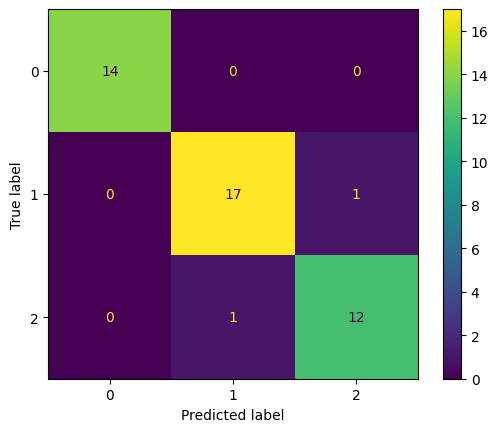

In [20]:
# plot_confusion_matrix(knn, xTest, yTest)
ConfusionMatrixDisplay.from_estimator(knn, xTest, yTest)

In [21]:
print("Accuracy: ", balanced_accuracy_score(yTest, knnPred))
print("F1: ", f1_score(yTest, knnPred, average='weighted'))
print("Loss: ", log_loss(yTest, knnProb))

Accuracy:  0.9558404558404558
F1:  0.9555555555555556
Loss:  0.0809210311306514


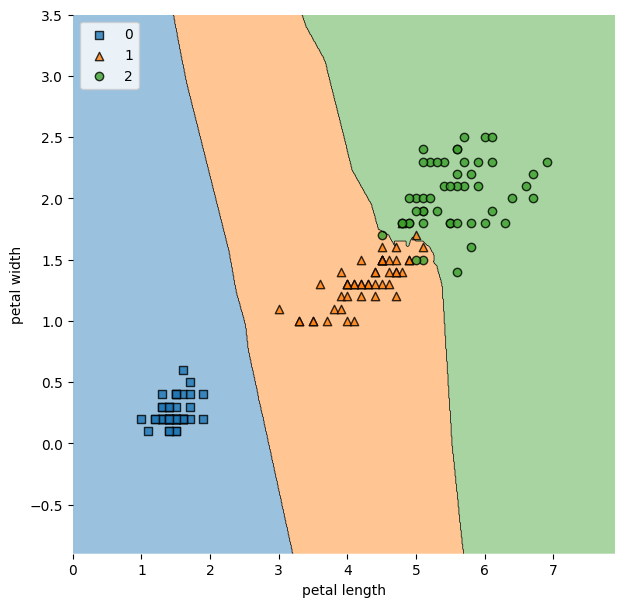

In [22]:
fig, ax = plt.subplots(figsize=(7,7))

plot_decision_regions(xCombined, yCombined, clf=knn)
plt.xlabel("petal length")
plt.ylabel("petal width")
plt.legend(loc='upper left')
#plt.tight_layout()
plt.show()

### A little more complex

In [23]:
breast_cancer = datasets.load_breast_cancer()
print(breast_cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [24]:
x = breast_cancer.data
y = breast_cancer.target

xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size=0.3, random_state=42)

## Logistic Regression

In [25]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=100)
lr.fit(xTrain, yTrain)

lrPred = lr.predict(xTest)
lrProb = lr.predict_proba(xTest)

print(classification_report(yTest, lrPred))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96        63
           1       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



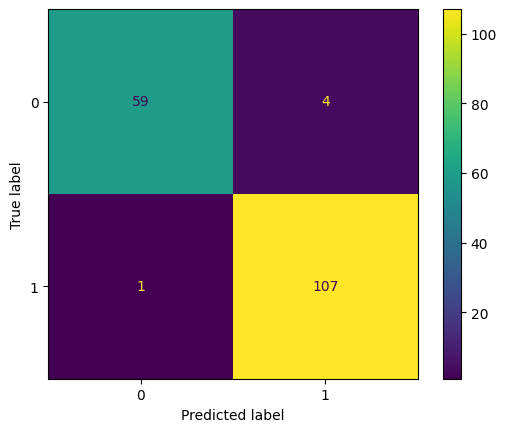

In [27]:
# plot_confusion_matrix(lr, xTest, yTest)
ConfusionMatrixDisplay.from_estimator(lr, xTest, yTest)

In [28]:
print("Accuracy: ", balanced_accuracy_score(yTest, lrPred))
print("F1: ", f1_score(yTest, lrPred, average='weighted'))
print("Loss: ", log_loss(yTest, lrProb))

Accuracy:  0.9636243386243386
F1:  0.970603923775359
Loss:  0.08003420998548395


## Gaussian Naive Bayes

In [30]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(xTrain, yTrain)

gnbPred = gnb.predict(xTest)
gnbProb = gnb.predict_proba(xTest)

print(classification_report(yTest, gnbPred))

              precision    recall  f1-score   support

           0       0.93      0.90      0.92        63
           1       0.95      0.96      0.95       108

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



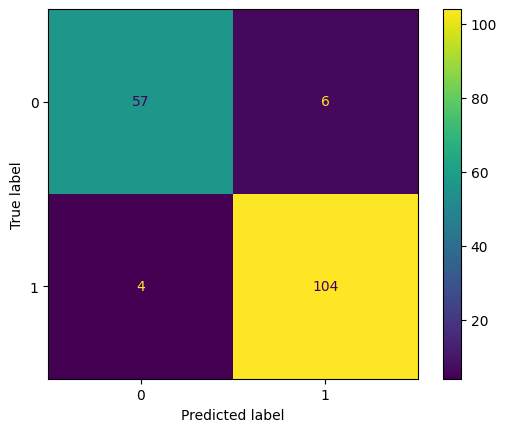

In [31]:
# plot_confusion_matrix(gnb, xTest, yTest)
ConfusionMatrixDisplay.from_estimator(gnb, xTest, yTest)

In [32]:
print("Accuracy: ", balanced_accuracy_score(yTest, gnbPred))
print("F1: ", f1_score(yTest, gnbPred, average='weighted'))
print("Loss: ", log_loss(yTest, gnbProb))

Accuracy:  0.9338624338624338
F1:  0.9413171134406007
Loss:  0.48986013210958873


## K-Nearest Neighbors

In [33]:
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(xTrain, yTrain)

knnPred = knn.predict(xTest)
knnProb = knn.predict_proba(xTest)

print(classification_report(yTest, knnPred))

              precision    recall  f1-score   support

           0       0.93      0.90      0.92        63
           1       0.95      0.96      0.95       108

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



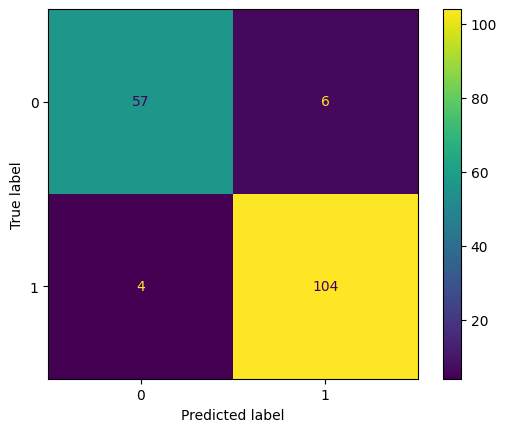

In [34]:
# plot_confusion_matrix(knn, xTest, yTest)
ConfusionMatrixDisplay.from_estimator(knn, xTest, yTest)

In [35]:
print("Accuracy: ", balanced_accuracy_score(yTest, knnPred))
print("F1: ", f1_score(yTest, knnPred, average='weighted'))
print("Loss: ", log_loss(yTest, knnProb))

Accuracy:  0.9338624338624338
F1:  0.9413171134406007
Loss:  0.09507116545080274


### Hyperparameter Optimization

In [36]:
from sklearn.model_selection import GridSearchCV

hyper_params = {
    'n_neighbors': range(1,16), #starting zero does not make sense. last element NOT included
    'p': range(1, 5)
}

# Too many hyperparameters
# Range is too big

grid = GridSearchCV(KNeighborsClassifier(), hyper_params)
grid.fit(xTrain, yTrain)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': range(1, 16), 'p': range(1, 5)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and 

In [37]:
grid.best_params_

{'n_neighbors': 5, 'p': 1}

In [38]:
knn_model = KNeighborsClassifier(n_neighbors = grid.best_params_['n_neighbors'], 
                                 p=grid.best_params_['p'])
knn_model.fit(xTrain, yTrain)

knn2Pred = knn_model.predict(xTest)
knn2Prob = knn_model.predict_proba(xTest)

print(classification_report(yTest, knn2Pred))

              precision    recall  f1-score   support

           0       0.97      0.92      0.94        63
           1       0.95      0.98      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



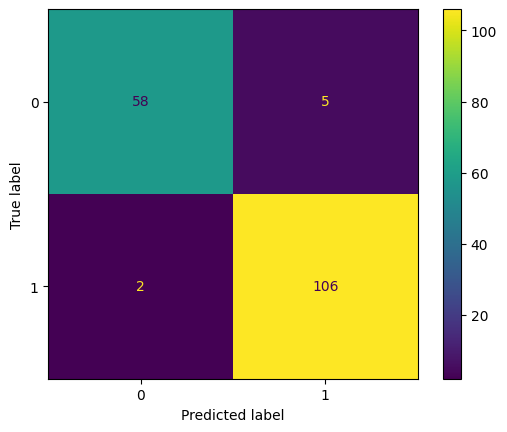

In [39]:
# plot_confusion_matrix(knn_model, xTest, yTest)
ConfusionMatrixDisplay.from_estimator(knn_model, xTest, yTest)

In [40]:
print("Accuracy: ", balanced_accuracy_score(yTest, knn2Pred))
print("F1: ", f1_score(yTest, knn2Pred, average='weighted'))
print("Loss: ", log_loss(yTest, knn2Prob))

Accuracy:  0.951058201058201
F1:  0.9588454932855025
Loss:  0.08304101740672246


### Cross Validation

<img src="cross_validation.png">

In [41]:
from sklearn.model_selection import cross_val_score

cross = cross_val_score(lr, x, y) #cv=5
print("Logistic Regression Accuracy: ", cross)

Logistic Regression Accuracy:  [0.93859649 0.92982456 0.95614035 0.94736842 0.95575221]


In [42]:
cross = cross_val_score(gnb, x, y)
print("Gaussian Naive Bayes Accuracy: ", cross)

Gaussian Naive Bayes Accuracy:  [0.92105263 0.92105263 0.94736842 0.94736842 0.95575221]


In [43]:
cross = cross_val_score(knn, x, y)
print("K Nearest Neighbors Accuracy: ", cross)

K Nearest Neighbors Accuracy:  [0.87719298 0.92105263 0.94736842 0.93859649 0.91150442]
